# CS5841/EE5841 Final Project: Human Activity Recognition using Smartphone Sensor Data

### Sabina Bimbi, Noelle Haviland, Memory Mhembere

---

## Project Overview

Human Activity Recognition (HAR) refers to the automatic identification of physical activities performed by individuals using sensor data collected from smartphones. This notebook implements and compares three deep learning architectures:

- **CNN** : Convolutional Neural Network: extracts spatial features from multichannel sensor signals
- **LSTM** : Long Short-Term Memory: models temporal dependencies in sequential sensor data
- **CNN-LSTM** : Hybrid architecture: captures both spatial and temporal patterns

**Dataset:** UCI Human Activity Recognition Using Smartphones  
**Source:** https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones  
**Activities classified:** Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import urllib.request
import zipfile
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv1D,
                                      MaxPooling1D, LSTM, Reshape,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Fixed seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Output directories
FIGURES_DIR = './figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print('All packages loaded successfully!')

2026-04-11 14:33:53.618947: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 14:33:53.702576: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-11 14:33:53.702655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-11 14:33:53.711653: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-11 14:33:53.744515: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version : 2.15.1
NumPy version      : 1.26.4
All packages loaded successfully!


## Data Loading and Exploration

The UCI HAR dataset contains raw inertial sensor signals (accelerometer and gyroscope) collected from 30 subjects performing 6 daily activities. Data was recorded at 50Hz using a Samsung Galaxy S II.

Each sample consists of a **128-timestep window** across **9 sensor channels**:
- Body acceleration (X, Y, Z)
- Body gyroscope (X, Y, Z)
- Total acceleration (X, Y, Z)

The dataset is downloaded automatically on first run and extracted to the `../data/` folder.

In [2]:
DATA_URL     = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip'
DATA_DIR     = './data'
ZIP_PATH     = os.path.join(DATA_DIR, 'UCI_HAR_Dataset.zip')
EXTRACT_PATH = os.path.join(DATA_DIR, 'UCI HAR Dataset')
BASE = './data/UCI HAR Dataset'
SIGNAL_NAMES = [
    'Body Acc X', 'Body Acc Y', 'Body Acc Z',
    'Body Gyro X', 'Body Gyro Y', 'Body Gyro Z',
    'Total Acc X', 'Total Acc Y', 'Total Acc Z'
]

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(BASE):
    print('Downloading UCI HAR Dataset...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print('Download complete. Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('Extraction complete!')
else:
    print('Dataset already exists locally.')

Dataset already exists locally.


In [3]:
def load_signals(subset, base_path):
    """
    Loading all 9 raw inertial sensor signal files for a given subset (train/test).
    Returns array of shape (n_samples, 128 timesteps, 9 channels).
    """
    signal_types = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    signals = []
    for sig in signal_types:
        path = os.path.join(base_path, subset, 'Inertial Signals',
                            f'{sig}_{subset}.txt')
        signals.append(
            pd.read_csv(path, sep=r'\s+', header=None, engine='python').values
        )
    return np.transpose(np.array(signals), (1, 2, 0))

def load_labels(subset, base_path):
    """Loading integer activity labels (1–6) for a given subset."""
    path = os.path.join(base_path, subset, f'y_{subset}.txt')
    return pd.read_csv(path, header=None).values.ravel()

def load_subjects(subset, base_path):
    """Loading subject IDs for cross-user generalization analysis."""
    path = os.path.join(base_path, subset, f'subject_{subset}.txt')
    return pd.read_csv(path, header=None).values.ravel()

X_train_raw    = load_signals('train', BASE)
X_test_raw     = load_signals('test',  BASE)
y_train_raw    = load_labels('train',  BASE)
y_test_raw     = load_labels('test',   BASE)
subjects_train = load_subjects('train', BASE)
subjects_test  = load_subjects('test',  BASE)

print(f'X_train shape          : {X_train_raw.shape}')  # (7352, 128, 9)
print(f'X_test  shape          : {X_test_raw.shape}')   # (2947, 128, 9)
print(f'Unique activity labels : {np.unique(y_train_raw)}')
print(f'Train subjects         : {np.unique(subjects_train)}')
print(f'Test subjects          : {np.unique(subjects_test)}')

pd.DataFrame(X_train_raw[0], columns=SIGNAL_NAMES).head()

X_train shape          : (7352, 128, 9)
X_test  shape          : (2947, 128, 9)
Unique activity labels : [1 2 3 4 5 6]
Train subjects         : [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Test subjects          : [ 2  4  9 10 12 13 18 20 24]


,Body Acc X,Body Acc Y,Body Acc Z,Body Gyro X,Body Gyro Y,Body Gyro Z,Total Acc X,Total Acc Y,Total Acc Z
0,0.000181,0.010767,0.055561,0.030191,0.066014,0.022859,1.012817,-0.123217,0.102934
1,0.010139,0.006579,0.055125,0.043711,0.042699,0.010316,1.022833,-0.126876,0.105687
2,0.009276,0.008929,0.048405,0.035688,0.074850,0.013250,1.022028,-0.124004,0.102102
3,0.005066,0.007489,0.049775,0.040402,0.057320,0.017751,1.017877,-0.124928,0.106553
4,0.010810,0.006141,0.043013,0.047097,0.052343,0.002553,1.023680,-0.125767,0.102814


## Exploratory Data Analysis (EDA)

Before building models, we explore the dataset to understand:
1. **Class distribution**: are activity classes balanced across train and test sets?
2. **Raw signal patterns** : what do the sensor signals look like for a sample window?

Understanding class balance is important because imbalanced classes can bias a model toward majority classes, inflating accuracy while performing poorly on mino

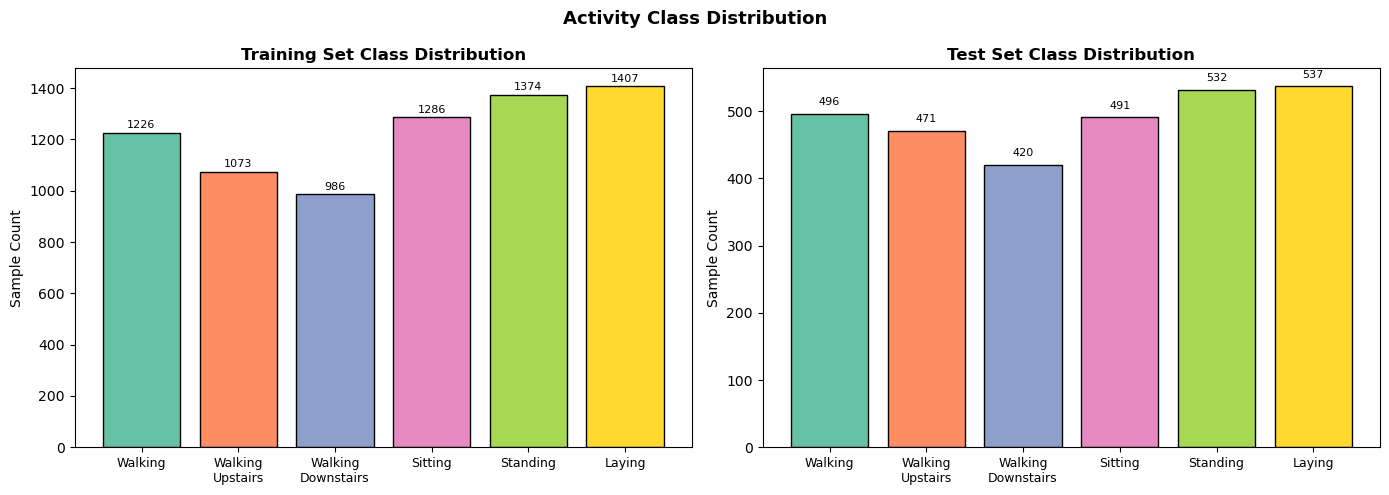

Figure saved: class_distribution.png


In [4]:
ACTIVITY_MAP = {
    1: 'Walking',
    2: 'Walking\nUpstairs',
    3: 'Walking\nDownstairs',
    4: 'Sitting',
    5: 'Standing',
    6: 'Laying'
}

# Class distribution across train and test sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y, title in zip(axes,
                        [y_train_raw, y_test_raw],
                        ['Training Set Class Distribution',
                         'Test Set Class Distribution']):
    counts = pd.Series(y).map(ACTIVITY_MAP).value_counts().reindex(
        list(ACTIVITY_MAP.values()))
    bars = ax.bar(range(len(counts)), counts.values,
                  color=sns.color_palette('Set2', 6), edgecolor='black')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 10,
                str(v), ha='center', va='bottom', fontsize=8)

plt.suptitle('Activity Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: class_distribution.png')

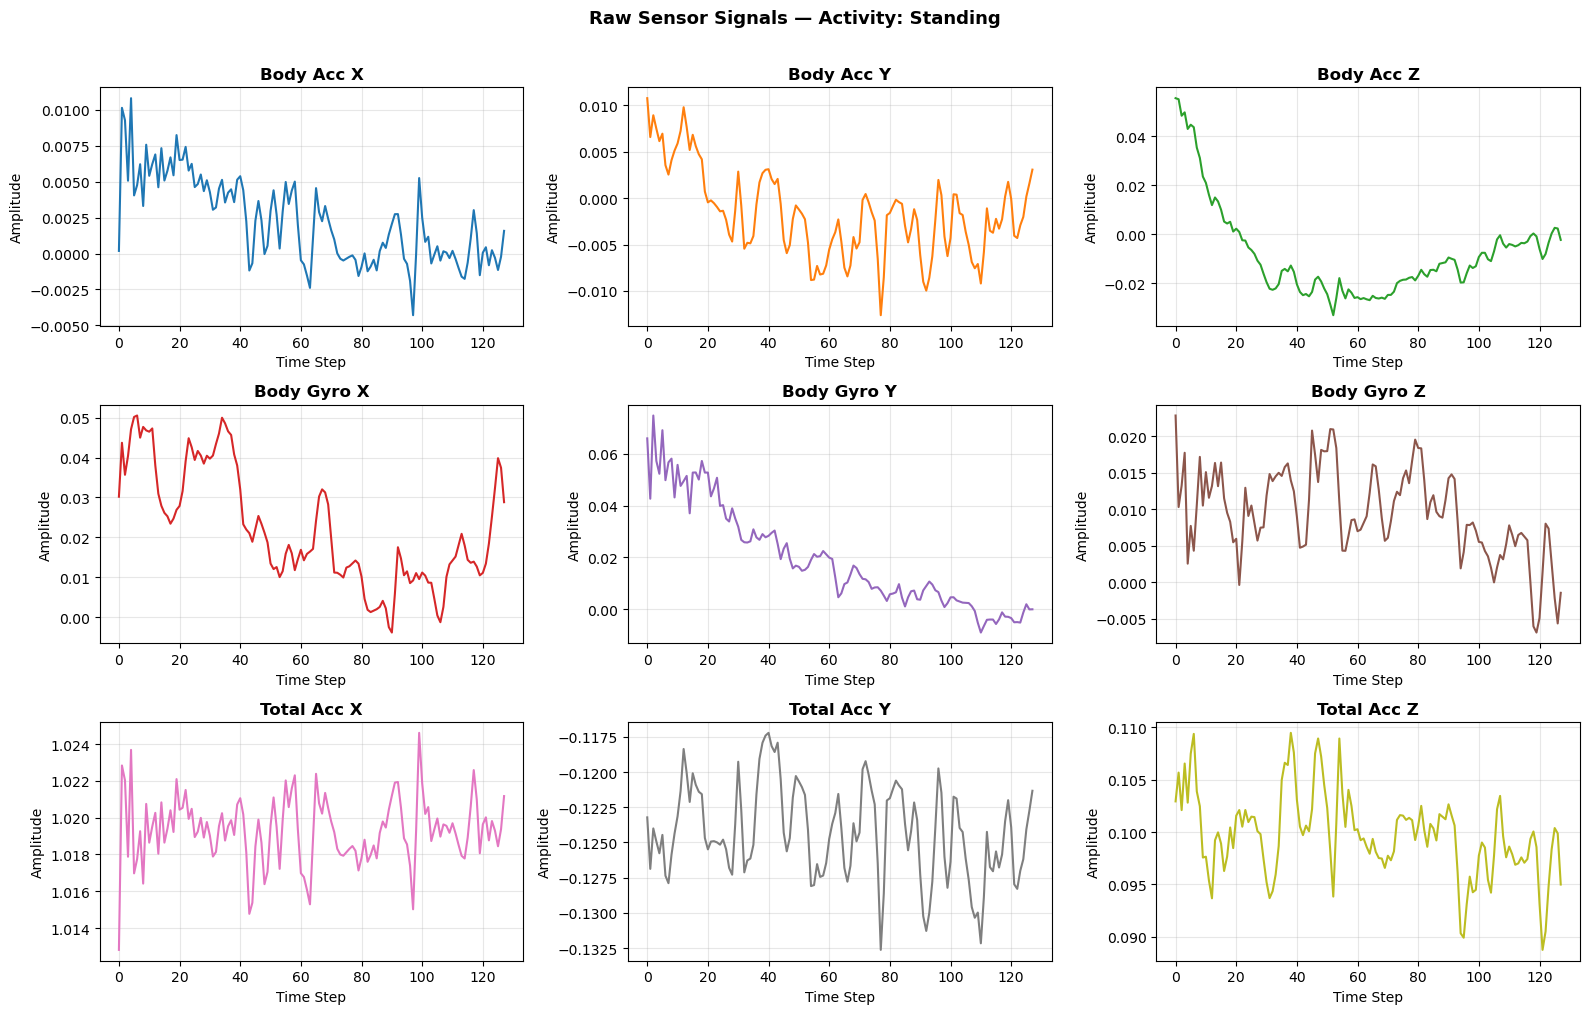

Figure saved: sample_signals.png


In [5]:
# Visualizing all 9 raw sensor signals for one sample window

sample_idx = 0
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (ax, name) in enumerate(zip(axes, SIGNAL_NAMES)):
    ax.plot(X_train_raw[sample_idx, :, i],
            color=sns.color_palette('tab10')[i])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

activity_label = ACTIVITY_MAP[y_train_raw[sample_idx]]
fig.suptitle(f'Raw Sensor Signals — Activity: {activity_label}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sample_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: sample_signals.png')

##  Data Preprocessing

Three preprocessing steps are applied before model training:

1. **Normalization (Z-score):** Each of the 9 sensor channels is standardized to zero mean and unit variance using statistics computed from the training set only. This prevents data leakage and ensures consistent input scale across channels.

2. **Label Encoding:** Activity labels (1–6) are converted to 0-based integers, then one-hot encoded for compatibility with the softmax output layer.

3. **Validation Split:**  The UCI HAR dataset comes pre-divided into a training set (7,352 samples) and a test set (2,947 samples), already split by subject to ensure no user overlap between splits.

To monitor model performance during training and enable early stopping, we further divide the training set into a training and validation set using an **85-15 split**:

- **Training set** — 6,249 samples (85%): used to update model weights
- **Validation set** — 1,103 samples (15%): used to monitor overfitting and trigger early stopping
- **Test set** — 2,947 samples (held out entirely until final evaluation)

The split is **stratified** by activity class to ensure each class is proportionally represented in both the training and validation sets. A fixed random seed (42) is used for reproducibility.

In [6]:
#Missing Value Check
train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
test_flat  = X_test_raw.reshape(X_test_raw.shape[0], -1)

missing_train = np.isnan(train_flat).sum()
missing_test  = np.isnan(test_flat).sum()
print(f'Missing values in training set : {missing_train}')
print(f'Missing values in test set     : {missing_test}')
print('=> No imputation needed.\n' if missing_train == 0 and missing_test == 0
      else '=> Missing values detected — imputation required.\n')

#Scaling Check 
print(f'Training set value range : [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]')
print(f'Test set value range     : [{X_test_raw.min():.4f},  {X_test_raw.max():.4f}]')
print('=> Z-score normalization will be applied per channel.\n')

# Label Encoding Check 
print(f'Unique raw labels (train) : {np.unique(y_train_raw)}  (1-based integers)')
print(f'Unique raw labels (test)  : {np.unique(y_test_raw)}')
print('=> Labels will be encoded to 0-based integers and one-hot encoded for Keras.\n')

# Z-score Normalization (using training set statistics only)
mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
std  = X_train_raw.std(axis=(0, 1),  keepdims=True) + 1e-8

X_train_norm = (X_train_raw - mean) / std
X_test_norm  = (X_test_raw  - mean) / std

# Label Encoding: 1–6 → 0–5 → one-hot 
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)
NUM_CLASSES = len(le.classes_)

y_train_oh = to_categorical(y_train_enc, NUM_CLASSES)
y_test_oh  = to_categorical(y_test_enc,  NUM_CLASSES)

# Validation Split: stratified 85-15 
X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_oh,
    test_size=0.15, random_state=42, stratify=y_train_enc
)

print(f'Number of classes : {NUM_CLASSES}')
print(f'Train set         : {X_train.shape[0]} samples')
print(f'Validation set    : {X_val.shape[0]} samples')
print(f'Test set          : {X_test_norm.shape[0]} samples')
print(f'Input shape       : {X_train.shape[1:]}  (128 timesteps x 9 channels)')

Missing values in training set : 0
Missing values in test set     : 0
=> No imputation needed.

Training set value range : [-5.9743, 5.7461]
Test set value range     : [-3.4317,  3.4681]
=> Z-score normalization will be applied per channel.

Unique raw labels (train) : [1 2 3 4 5 6]  (1-based integers)
Unique raw labels (test)  : [1 2 3 4 5 6]
=> Labels will be encoded to 0-based integers and one-hot encoded for Keras.

Number of classes : 6
Train set         : 6249 samples
Validation set    : 1103 samples
Test set          : 2947 samples
Input shape       : (128, 9)  (128 timesteps x 9 channels)


## Model Definitions

We define three architectures for comparison:

### CNN
Three stacked Conv1D layers with BatchNormalization, MaxPooling, and Dropout extract local spatial features from the 128-timestep signal windows. A Dense layer produces the final class probabilities.

### LSTM
Two stacked LSTM layers capture long-range temporal dependencies in the sequential sensor data. The first LSTM returns sequences so the second can process the full temporal context.

### CNN-LSTM (Hybrid)
CNN layers first extract local spatial features, then the output is reshaped into super-steps and passed to LSTM layers for temporal modeling. This architecture captures both fine-grained spatial patterns and long-range temporal dependencies.

All models use:
- **Adam optimizer** with adaptive learning rate reduction on plateau
- **Categorical cross-entropy loss**
- **Early stopping** (patience=10) to prevent overfitting
- **Dropout** for regularization

In [7]:
TIMESTEPS  = X_train.shape[1]   # 128
FEATURES   = X_train.shape[2]   # 9
EPOCHS     = 50
BATCH_SIZE = 64

def get_callbacks():
    """Early stopping + learning rate reduction callbacks shared across all models."""
    return [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, verbose=0)
    ]

## Convolutional Neural Network (CNN)

In [8]:
# Three Conv1D blocks progressively extract spatial features from sensor signals.
# BatchNorm stabilizes training; MaxPooling reduces dimensionality;
# Dropout prevents overfitting.

def build_cnn(timesteps, features, num_classes):
    model = Sequential([
        Input(shape=(timesteps, features)),

        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ], name='CNN')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn(TIMESTEPS, FEATURES, NUM_CLASSES)
cnn_model.summary()

Model: "CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 128, 64)           1792      
                                                                 
 batch_normalization (Batch  (None, 128, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 64, 64)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 64, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 64, 128)           24704     
                                                                 
 batch_normalization_1 (Bat  (None, 64, 128)           512     

### CNN Training

In [9]:
print('=' * 55)
print('Training CNN...')
print('=' * 55)
cnn_history = cnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(),
    verbose=1
)

Training CNN...
Epoch 1/50
196/196 [==============================] - 4s 17ms/step - loss: 0.6659 - accuracy: 0.7603 - val_loss: 0.4992 - val_accuracy: 0.8005 - lr: 0.0010
Epoch 2/50
196/196 [==============================] - 3s 16ms/step - loss: 0.2252 - accuracy: 0.9145 - val_loss: 0.1254 - val_accuracy: 0.9411 - lr: 0.0010
Epoch 3/50
196/196 [==============================] - 3s 16ms/step - loss: 0.1674 - accuracy: 0.9341 - val_loss: 0.1065 - val_accuracy: 0.9574 - lr: 0.0010
Epoch 4/50
196/196 [==============================] - 3s 15ms/step - loss: 0.1573 - accuracy: 0.9371 - val_loss: 0.1088 - val_accuracy: 0.9565 - lr: 0.0010
Epoch 5/50
196/196 [==============================] - 3s 15ms/step - loss: 0.1525 - accuracy: 0.9382 - val_loss: 0.0984 - val_accuracy: 0.9529 - lr: 0.0010
Epoch 6/50
196/196 [==============================] - 3s 16ms/step - loss: 0.1425 - accuracy: 0.9429 - val_loss: 0.1001 - val_accuracy: 0.9574 - lr: 0.0010
Epoch 7/50
196/196 [============================

### CNN Evaluation

So far, the CNN model has a validation acccuracy of 0.9719, suggesting that this model is able to generalize to unseen data.

## Long Short Term Memory (LSTM) Network

In [10]:
# Two stacked LSTM layers model sequential dependencies across the 128 timesteps.
# return_sequences=True in the first layer feeds the full sequence to the second.

def build_lstm(timesteps, features, num_classes):
    model = Sequential([
        Input(shape=(timesteps, features)),

        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm(TIMESTEPS, FEATURES, NUM_CLASSES)
lstm_model.summary()

Model: "LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 128, 128)          70656     
                                                                 
 dropout_4 (Dropout)         (None, 128, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 64)                4160      
                                                                 
 dropout_6 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 6)                 390    

### LSTM Training

In [11]:
def build_lstm(timesteps, features, num_classes):
    model = Sequential([
        Input(shape=(timesteps, features)),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [12]:
print('=' * 55)
print('Training LSTM...')
print('=' * 55)
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(),
    verbose=1
)

Training LSTM...
Epoch 1/50
196/196 [==============================] - 22s 103ms/step - loss: 0.5770 - accuracy: 0.7904 - val_loss: 0.1852 - val_accuracy: 0.9266 - lr: 0.0010
Epoch 2/50
196/196 [==============================] - 19s 100ms/step - loss: 0.3859 - accuracy: 0.8411 - val_loss: 0.2602 - val_accuracy: 0.9175 - lr: 0.0010
Epoch 3/50
196/196 [==============================] - 21s 105ms/step - loss: 0.2442 - accuracy: 0.9137 - val_loss: 0.5456 - val_accuracy: 0.8350 - lr: 0.0010
Epoch 4/50
196/196 [==============================] - 19s 98ms/step - loss: 0.2693 - accuracy: 0.9049 - val_loss: 0.1329 - val_accuracy: 0.9619 - lr: 0.0010
Epoch 5/50
196/196 [==============================] - 20s 101ms/step - loss: 0.1494 - accuracy: 0.9435 - val_loss: 0.1289 - val_accuracy: 0.9492 - lr: 0.0010
Epoch 6/50
196/196 [==============================] - 20s 103ms/step - loss: 0.1300 - accuracy: 0.9514 - val_loss: 0.1145 - val_accuracy: 0.9610 - lr: 0.0010
Epoch 7/50
196/196 [================

### LSTM Evaluation

The LSTM model has a validation accuracy of 0.9619, which is slightly lower than that of the CNN model. It will still likely generalize well to unseen data. It also has a smaller learning rate, suggesting better convergence. However, this is the result of the model run only on CPU. We are in the process of running the model on GPU, which may give different results.

## Combined CNN/LSTM

In [13]:
# Stage 1: Two Conv1D blocks reducing the 128-step signal to 32 feature-rich steps.
# Stage 2: Reshaping groups every 4 CNN outputs into one LSTM super-step (8 total).
# Stage 3: LSTM layers learn temporal patterns across those 8 super-steps.
# This two-stage design captures both local spatial patterns and global temporal context.

def build_cnn_lstm(timesteps, features, num_classes):
    model = Sequential([
        Input(shape=(timesteps, features)),

        # Spatial feature extraction
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),   # → (64, 64)
        Dropout(0.3),

        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),   # → (32, 128)
        Dropout(0.3),

        # Reshape: 32 CNN steps → 8 LSTM super-steps of 512 features each
        Reshape((8, 4 * 128)),

        # Temporal modeling
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='CNN_LSTM')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_lstm_model = build_cnn_lstm(TIMESTEPS, FEATURES, NUM_CLASSES)
cnn_lstm_model.summary()

Model: "CNN_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 128, 64)           1792      
                                                                 
 batch_normalization_3 (Bat  (None, 128, 64)           256       
 chNormalization)                                                
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 64, 64)            0         
 g1D)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 64, 64)            0         
                                                                 
 conv1d_4 (Conv1D)           (None, 64, 128)           24704     
                                                                 
 batch_normalization_4 (Bat  (None, 64, 128)           512

### Combined Model Training

In [14]:
print('=' * 55)
print('Training CNN-LSTM...')
print('=' * 55)
cnn_lstm_history = cnn_lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(),
    verbose=1
)

Training CNN-LSTM...
Epoch 1/50
196/196 [==============================] - 8s 30ms/step - loss: 0.4387 - accuracy: 0.8427 - val_loss: 0.1360 - val_accuracy: 0.9619 - lr: 0.0010
Epoch 2/50
196/196 [==============================] - 5s 24ms/step - loss: 0.1570 - accuracy: 0.9398 - val_loss: 0.0947 - val_accuracy: 0.9628 - lr: 0.0010
Epoch 3/50
196/196 [==============================] - 5s 26ms/step - loss: 0.1408 - accuracy: 0.9459 - val_loss: 0.1115 - val_accuracy: 0.9565 - lr: 0.0010
Epoch 4/50
196/196 [==============================] - 5s 27ms/step - loss: 0.1303 - accuracy: 0.9482 - val_loss: 0.1019 - val_accuracy: 0.9547 - lr: 0.0010
Epoch 5/50
196/196 [==============================] - 5s 27ms/step - loss: 0.1289 - accuracy: 0.9458 - val_loss: 0.1134 - val_accuracy: 0.9592 - lr: 0.0010
Epoch 6/50
196/196 [==============================] - 5s 26ms/step - loss: 0.1292 - accuracy: 0.9448 - val_loss: 0.0975 - val_accuracy: 0.9583 - lr: 0.0010
Epoch 7/50
196/196 [=======================

### Combined Model Evaluation

The combined CNN/LSTM model has the highest validation accuracy (0.9764) and lowest validation loss. This is consistent with our hypothesis in our project proposal. However, we may once again achieve better performance after running the model on GPU via high-performance computing access.

## Training Curves

Learning curves show how training and validation loss/accuracy evolve across epochs. Healthy curves show:
- Both train and val loss decreasing together (no overfitting)
- Val accuracy converging close to train accuracy

A large gap between train and val curves would indicate overfitting. Early stopping ensures we use the best checkpoint.

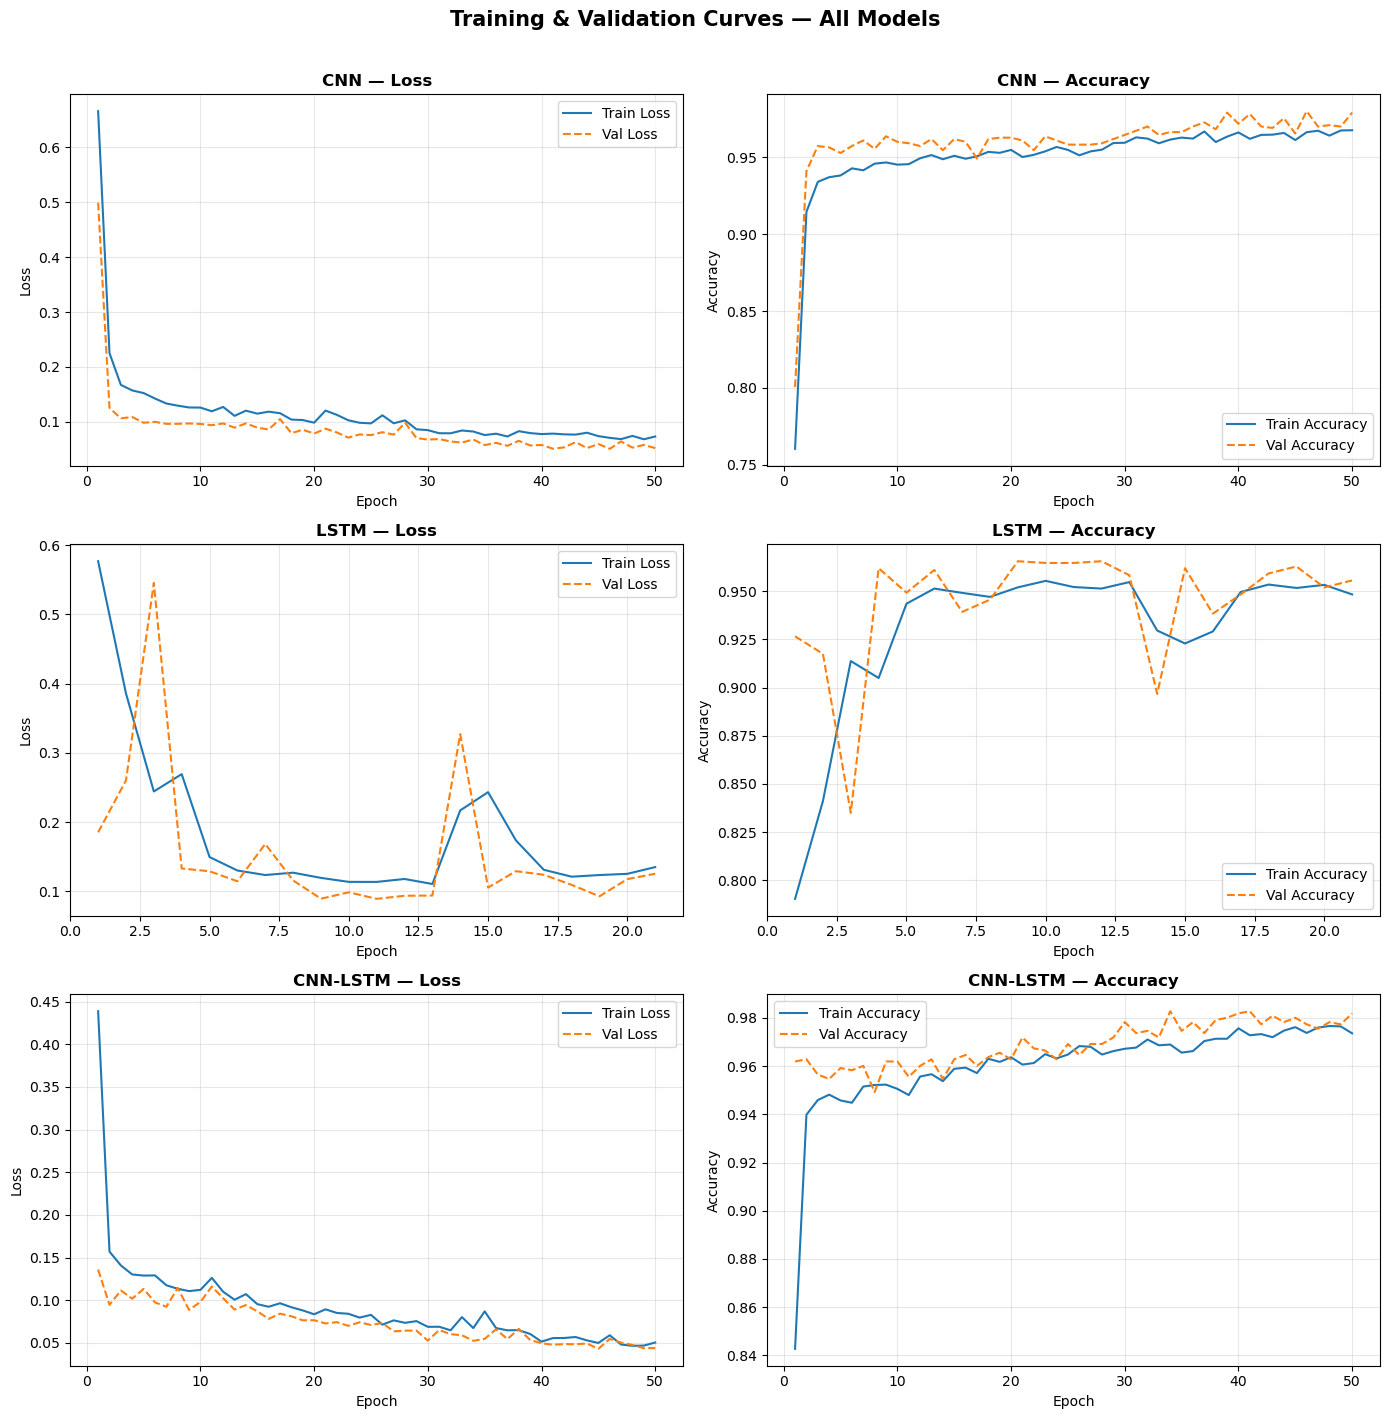

Figure saved: training_curves.png


In [15]:
def plot_history(history, model_name, axes_row):
    
    ax_loss, ax_acc = axes_row
    epochs = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs, history.history['loss'],     label='Train Loss')
    ax_loss.plot(epochs, history.history['val_loss'], label='Val Loss', linestyle='--')
    ax_loss.set_title(f'{model_name} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, history.history['accuracy'],     label='Train Accuracy')
    ax_acc.plot(epochs, history.history['val_accuracy'], label='Val Accuracy', linestyle='--')
    ax_acc.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for hist, name, row in zip(
    [cnn_history, lstm_history, cnn_lstm_history],
    ['CNN', 'LSTM', 'CNN-LSTM'],
    axes
):
    plot_history(hist, name, row)

plt.suptitle('Training & Validation Curves — All Models',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: training_curves.png')

## Evaluation on Test Set

Each trained model is evaluated on the held-out test set (2,947 samples from unseen subjects). We report four metrics:

- **Accuracy** — overall percentage of correctly classified samples
- **Precision** — of all predicted positives, how many were actually positive (weighted average across classes)
- **Recall** — of all actual positives, how many were correctly identified
- **F1-Score** — harmonic mean of precision and recall; the primary comparison metric

The per-class classification report reveals which specific activities are harder to distinguish (e.g., sitting vs. standing tend to be confused more often).

In [16]:
CLASS_NAMES = ['Walking', 'Walking Upstairs', 'Walking Downstairs',
               'Sitting', 'Standing', 'Laying']

def evaluate_model(model, X_test, y_test_enc, model_name):
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc  = accuracy_score(y_test_enc,  y_pred)
    prec = precision_score(y_test_enc, y_pred, average='weighted')
    rec  = recall_score(y_test_enc,    y_pred, average='weighted')
    f1   = f1_score(y_test_enc,        y_pred, average='weighted')

    print(f'\n{"-" * 55}')
    print(f'  Model     : {model_name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{"-" * 55}')
    print(classification_report(y_test_enc, y_pred, target_names=CLASS_NAMES))

    return y_pred, {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

y_pred_cnn,      metrics_cnn      = evaluate_model(cnn_model,      X_test_norm, y_test_enc, 'CNN')
y_pred_lstm,     metrics_lstm     = evaluate_model(lstm_model,     X_test_norm, y_test_enc, 'LSTM')
y_pred_cnn_lstm, metrics_cnn_lstm = evaluate_model(cnn_lstm_model, X_test_norm, y_test_enc, 'CNN-LSTM')


-------------------------------------------------------
  Model     : CNN
  Accuracy  : 0.9233
  Precision : 0.9230
  Recall    : 0.9233
  F1-Score  : 0.9230
-------------------------------------------------------
                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       496
  Walking Upstairs       0.97      0.95      0.96       471
Walking Downstairs       0.95      0.97      0.96       420
           Sitting       0.82      0.78      0.80       491
          Standing       0.82      0.85      0.83       532
            Laying       0.99      1.00      0.99       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947


-------------------------------------------------------
  Model     : LSTM
  Accuracy  : 0.9192
  Precision : 0.9200
  Recall    : 0.9192
  F1-Score  : 0.9190
----------------------

## Confusion Matrices

Confusion matrices show the full breakdown of predicted vs. actual activity labels for each model. Values are expressed as percentages of each true class (row-normalized) so we can see relative error patterns regardless of class size.

Key things to look for:
- Strong diagonal → model predicts correctly most of the time
- Off-diagonal clusters → specific activities being confused with each other
- Static activities (Sitting/Standing) often show more confusion than dynamic ones (Walking)

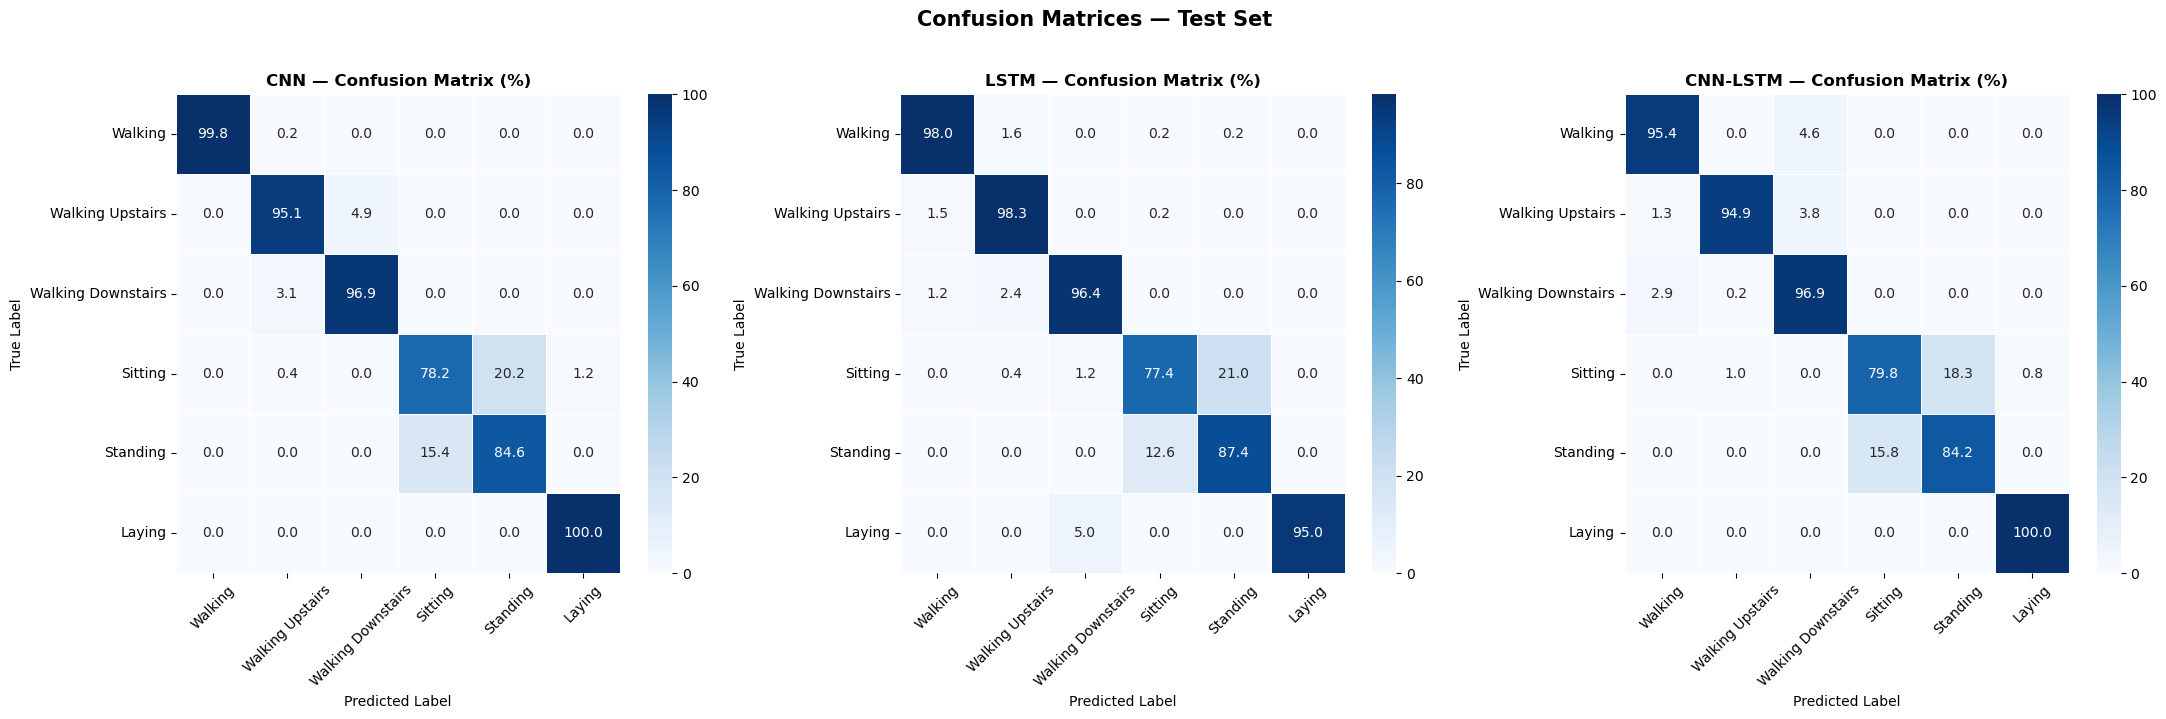

Figure saved: confusion_matrices.png


In [17]:
def plot_confusion(y_true, y_pred, model_name, ax):
    
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{model_name} — Confusion Matrix (%)', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, y_pred, name in zip(
    axes,
    [y_pred_cnn, y_pred_lstm, y_pred_cnn_lstm],
    ['CNN', 'LSTM', 'CNN-LSTM']
):
    plot_confusion(y_test_enc, y_pred, name, ax)

plt.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: confusion_matrices.png')

## Model Comparison

We compare all three models side by side using a summary table and a grouped bar chart. This gives a clear visual answer to which architecture performs best on this dataset and by how much.

The CNN-LSTM hybrid is expected to outperform both standalone models because it leverages both spatial feature extraction and temporal sequence modeling simultaneously.


Model Comparison Summary:
          Accuracy  Precision  Recall  F1-Score
CNN         0.9233     0.9230  0.9233    0.9230
LSTM        0.9192     0.9200  0.9192    0.9190
CNN-LSTM    0.9175     0.9177  0.9175    0.9174


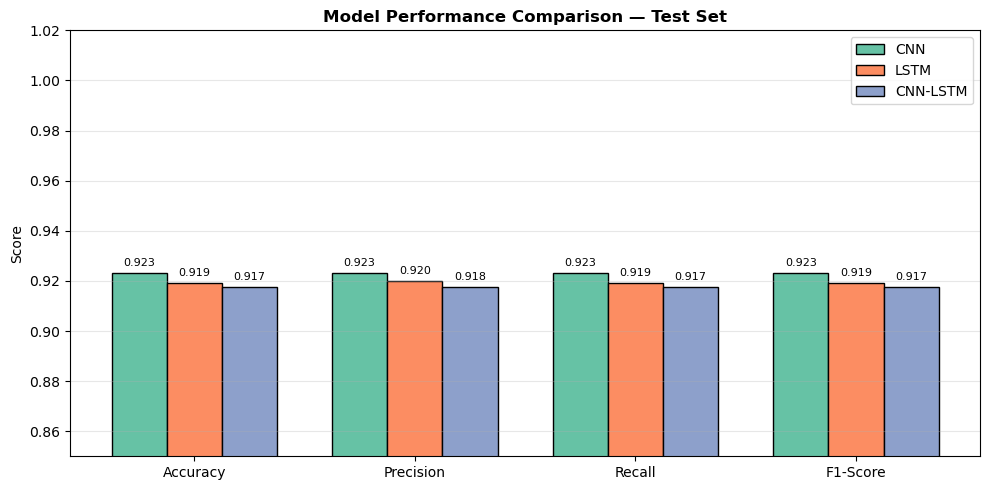

Figure saved: model_comparison.png


In [18]:
results_df = pd.DataFrame(
    [metrics_cnn, metrics_lstm, metrics_cnn_lstm],
    index=['CNN', 'LSTM', 'CNN-LSTM']
).round(4)

print('\nModel Comparison Summary:')
print(results_df.to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(results_df.columns))
width  = 0.25
colors = sns.color_palette('Set2', 3)

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model_name, color=colors[i], edgecolor='black')
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Test Set', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: model_comparison.png')

## Cross-User Generalization Analysis

A model that generalizes well across users is critical for real-world deployment — in healthcare or fitness applications, the model must work reliably for people it has never seen before.

The UCI dataset was intentionally split by subject: the 21 training subjects and 9 test subjects are completely different people. This means our test set already represents a cross-user evaluation.

Here we go further and compute per-subject accuracy for the best model, revealing how performance varies across individuals. High variance would indicate the model struggles to generalize to certain users.

In [19]:
print('Subject split confirmation:')
print(f'  Training subjects : {np.unique(subjects_train)}')
print(f'  Test subjects     : {np.unique(subjects_test)}')
print(f'\n  No overlap — test subjects are completely unseen users.')
print(f'  This confirms our evaluation is a true cross-user generalization test.')

Subject split confirmation:
  Training subjects : [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
  Test subjects     : [ 2  4  9 10 12 13 18 20 24]

  No overlap — test subjects are completely unseen users.
  This confirms our evaluation is a true cross-user generalization test.


In [20]:
# Use the best-performing model (update name below if CNN or LSTM wins)
best_model = cnn_model
best_name  = 'CNN'

# Compute accuracy for each individual test subject
subject_accs = {}
for subj in np.unique(subjects_test):
    mask  = subjects_test == subj
    X_s   = X_test_norm[mask]
    y_s   = y_test_enc[mask]
    preds = np.argmax(best_model.predict(X_s, verbose=0), axis=1)
    subject_accs[subj] = accuracy_score(y_s, preds)

subj_df = pd.Series(subject_accs).sort_index()

print(f'Per-Subject Accuracy — {best_name}:')
print(subj_df.to_string())
print(f'\nMean accuracy : {subj_df.mean():.4f}')
print(f'Std deviation : {subj_df.std():.4f}  (lower = more consistent across users)')
print(f'Min           : {subj_df.min():.4f}  (Subject {subj_df.idxmin()})')
print(f'Max           : {subj_df.max():.4f}  (Subject {subj_df.idxmax()})')

Per-Subject Accuracy — CNN:
2     0.897351
4     0.880126
9     0.871528
10    0.714286
12    0.946875
13    1.000000
18    1.000000
20    0.994350
24    0.955381

Mean accuracy : 0.9178
Std deviation : 0.0915  (lower = more consistent across users)
Min           : 0.7143  (Subject 10)
Max           : 1.0000  (Subject 13)


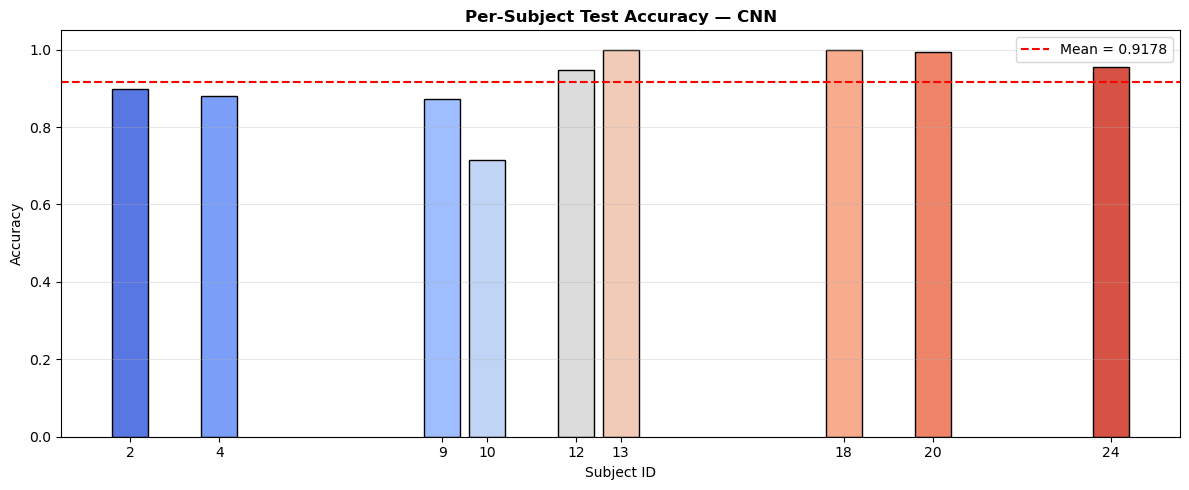

Figure saved: per_subject_accuracy.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(subj_df.index, subj_df.values,
              color=sns.color_palette('coolwarm', len(subj_df)),
              edgecolor='black')
ax.axhline(subj_df.mean(), color='red', linestyle='--',
           label=f'Mean = {subj_df.mean():.4f}')
ax.set_xlabel('Subject ID')
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-Subject Test Accuracy — {best_name}', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_xticks(subj_df.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'per_subject_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: per_subject_accuracy.png')

## Model Complexity Analysis

For real-world deployment on smartphones or wearable devices, accuracy alone is not sufficient. A model must also be:
- **Lightweight** — fewer parameters means less memory usage
- **Fast** — low inference time enables real-time activity recognition

We analyze the trade-off between model complexity (parameter count) and performance (accuracy), helping identify the most deployment-ready architecture.

In [22]:
models_list = [
    ('CNN',      cnn_model,      metrics_cnn),
    ('LSTM',     lstm_model,     metrics_lstm),
    ('CNN-LSTM', cnn_lstm_model, metrics_cnn_lstm)
]

complexity = []
for name, model, metrics in models_list:
    params = model.count_params()
    # Average inference time over 3 runs for stability
    times = []
    for _ in range(3):
        t0 = time.time()
        model.predict(X_test_norm, batch_size=256, verbose=0)
        times.append(time.time() - t0)
    inf_time = np.mean(times)
    complexity.append({
        'Model'              : name,
        'Parameters'         : params,
        'Inference Time (s)' : round(inf_time, 3),
        'Test Accuracy'      : metrics['Accuracy'],
        'F1-Score'           : metrics['F1-Score']
    })

complexity_df = pd.DataFrame(complexity).set_index('Model')
print('Model Complexity Analysis:')
print(complexity_df.to_string())

Model Complexity Analysis:
          Parameters  Inference Time (s)  Test Accuracy  F1-Score
Model                                                            
CNN           184134               0.177       0.923312  0.922985
LSTM          124614               1.602       0.919240  0.918970
CNN-LSTM      409414               0.280       0.917543  0.917391


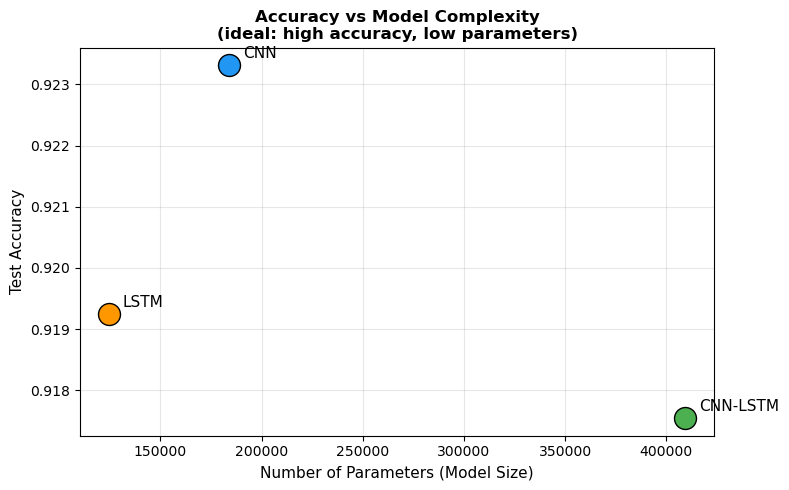

Figure saved: accuracy_vs_complexity.png


In [23]:
# Accuracy vs number of parameters — ideal model is top-left (high acc, few params)
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {'CNN': '#2196F3', 'LSTM': '#FF9800', 'CNN-LSTM': '#4CAF50'}

for _, row in complexity_df.reset_index().iterrows():
    ax.scatter(row['Parameters'], row['Test Accuracy'],
               s=250, color=colors_map[row['Model']],
               edgecolors='black', zorder=5)
    ax.annotate(row['Model'],
                (row['Parameters'], row['Test Accuracy']),
                textcoords='offset points', xytext=(10, 5), fontsize=11)

ax.set_xlabel('Number of Parameters (Model Size)', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Accuracy vs Model Complexity\n(ideal: high accuracy, low parameters)',
             fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'accuracy_vs_complexity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: accuracy_vs_complexity.png')

## Final Summary
This section prints a consolidated summary of all results including dataset details, train/val/test split sizes, metric scores for all three models, complexity figures, and the best-performing model identified by F1-Score.

In [24]:
best = results_df['F1-Score'].idxmax()

print('=' * 65)
print('        FINAL RESULTS SUMMARY — Group 4 HAR Project')
print('=' * 65)
print(f'\nDataset  : UCI Human Activity Recognition (10,299 samples, 6 classes)')
print(f'Subjects : 30 total  |  21 train  |  9 test (no overlap)')
print(f'Split    : {X_train.shape[0]} train  |  {X_val.shape[0]} val  |  {X_test_norm.shape[0]} test')
print(f'\nPerformance Metrics (Test Set):')
print(results_df.to_string())
print(f'\nModel Complexity:')
print(complexity_df[['Parameters', 'Inference Time (s)']].to_string())
print(f'\nCross-User Generalization ({best_name}):')
print(f'  Mean accuracy across {len(subj_df)} unseen subjects : {subj_df.mean():.4f}')
print(f'  Std deviation                         : {subj_df.std():.4f}')
print(f'\nBest model (by F1-Score) : {best}')
print(f'  Accuracy : {results_df.loc[best, "Accuracy"]:.4f}')
print(f'  F1-Score : {results_df.loc[best, "F1-Score"]:.4f}')
print(f'\nFigures saved to: ../figures/')
print('=' * 65)

        FINAL RESULTS SUMMARY — Group 4 HAR Project

Dataset  : UCI Human Activity Recognition (10,299 samples, 6 classes)
Subjects : 30 total  |  21 train  |  9 test (no overlap)
Split    : 6249 train  |  1103 val  |  2947 test

Performance Metrics (Test Set):
          Accuracy  Precision  Recall  F1-Score
CNN         0.9233     0.9230  0.9233    0.9230
LSTM        0.9192     0.9200  0.9192    0.9190
CNN-LSTM    0.9175     0.9177  0.9175    0.9174

Model Complexity:
          Parameters  Inference Time (s)
Model                                   
CNN           184134               0.177
LSTM          124614               1.602
CNN-LSTM      409414               0.280

Cross-User Generalization (CNN):
  Mean accuracy across 9 unseen subjects : 0.9178
  Std deviation                         : 0.0915

Best model (by F1-Score) : CNN
  Accuracy : 0.9233
  F1-Score : 0.9230

Figures saved to: ../figures/


## Discussion and Conclusion

Surprisingly, the model with the best performance on the test set was the simple convolutional neural network. We expected the combined CNN/LSTM architecture to have the best performance becuase it is, theoretically, best able to capture both spatial and temporal patterns in the sensor data. Even the worst-performing model had metrics above 0.9, suggesting that these model architectures are very effective at predicting activity types from smartphone sensor data. Key challenges we faced were complexity of the LSTM and CNN/LSTM architecture on CPU. We had to reduce the architecture of the LSTM and hybrid model, which may partially explain why the CNN performed the best. We are currently in the process of running the models on GPU, which may produce different results and align more with our expected outcome. Fortunately, we seemingly have not encountered the expected challenge of the models learning sensor noise. Future work may include cross-dataset validation to ensure our model generalizes well. Additional future work might involve real-time deployment of our best-working model to a sensor tool that people can use.